In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
EMBEDDED_DATA = "/home/rohit_vastani/Desktop/New Project/data/embeddings"
NAME = "indic_bert_v3.npy"

PATH = os.path.join(EMBEDDED_DATA , NAME)

# Load the data
X = np.load(PATH)

In [3]:
X.shape

(4000, 2560)

In [39]:
from sklearn.decomposition import PCA

pca = PCA()
X_reduced = pca.fit_transform(X)

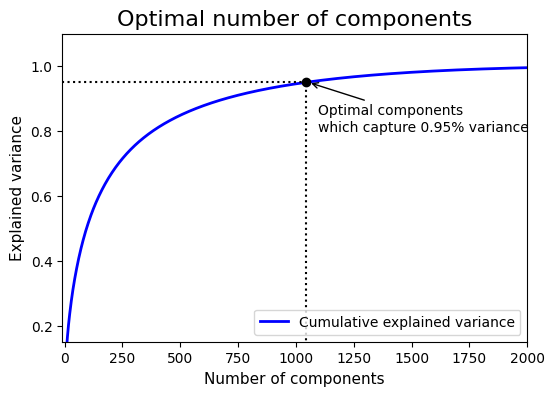

In [40]:
cumsum_var_ratio = np.cumsum(pca.explained_variance_ratio_)
var_ratio = 0.95
opti_compo = np.argmax(cumsum_var_ratio >= var_ratio) + 1

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), cumsum_var_ratio, "b", linewidth=2, label="Cumulative explained variance")
plt.plot([opti_compo , opti_compo] , [0 , var_ratio] , "k:")
plt.plot([-10 , opti_compo], [var_ratio , var_ratio], "k:")
plt.plot(opti_compo , var_ratio , "ko")
plt.annotate("Optimal components \nwhich capture {}% variance".format(var_ratio),
             xy=(opti_compo + 10, var_ratio),
             xytext=(opti_compo + 50, 0.80),
             arrowprops=dict(arrowstyle="->")
             )
plt.axis([-10 , 2000 , 0.15 , 1.1])
plt.xlabel("Number of components" , fontsize=11)
plt.ylabel("Explained variance", fontsize=11)
plt.title("Optimal number of components", fontsize=16)
plt.legend(loc="lower right")
plt.show()

In [41]:
opti_compo

np.int64(1044)

In [42]:
from sklearn.decomposition import PCA

# we get the optimal dimensions for the data
pca = PCA(n_components=opti_compo, random_state=42)
X_reduced = pca.fit_transform(X)

In [43]:
ARRAY_PATH = "/home/rohit_vastani/Desktop/New Project/data/reduced"
os.makedirs(ARRAY_PATH, exist_ok=True)

SAVING_FILE_PATH = os.path.join(ARRAY_PATH , "reduced_v3.npy")
np.save(SAVING_FILE_PATH , X_reduced)